# KNN (K-Nearest Neighbors) Algorithm with Classification - Health Risk Dataset

KNN algoritmasının sınıflandırma amacıyla kullanımı asagıdaki adımlarla ozetlenebilir:
1. Bir k degeri (komsu sayısı) belirlenir.
2. Yeni gelen test verisi icin egitim veri setindeki tum orneklerle mesafe hesaplanır.
3. Mesafesi en yakın k ornek secilir.
4. Bu k kom¸sunun sınıf etiketleri sayılarak en sık gorulen sınıf etiketi tahmin edilir.

KNN algoritması asagıdaki durumlarda iyi calısır:
- Veri boyutu cok yuksek degilse
- Ozellikler benzer olcekteyse (ozellik muhendisligi ve olcekleme yapılmıssa)
- Sınıflar arasındaki ayrım netse

> KNN, özellikle sınıflar arasında belirgin bir ayrım olduğunda, küçük veri setlerinde ve düşük boyutlu özelliklerde iyi performans gösterebilir, ancak büyük veri setlerinde ve yüksek boyutlu özelliklerde performansı düşebilir. Bu nedenle, modelin performansını değerlendirmek için uygun metrikler kullanılarak test verisi üzerinde değerlendirme yapılmalıdır.

In [1]:
import pandas as pd # Veri işleme ve analiz için kullanılan bir kütüphanedir. Veri setlerini yüklemek, temizlemek, manipüle etmek ve analiz etmek için kullanılır.
import seaborn as sns # Veri görselleştirme için kullanılan bir kütüphanedir. Seaborn, Matplotlib üzerine inşa edilmiştir ve istatistiksel grafikler oluşturmak için daha yüksek seviyeli bir arayüz sağlar.
import matplotlib.pyplot as plt # Veri görselleştirme için kullanılan bir kütüphanedir. Matplotlib, 2D grafikler oluşturmak için geniş bir araç seti sunar.

from sklearn.model_selection import train_test_split # Veri setini eğitim ve test setlerine bölmek için kullanılan bir fonksiyondur. Bu, modelin performansını değerlendirmek için önemlidir, çünkü modelin daha önce görmediği veriler üzerinde nasıl performans gösterdiğini görmek gerekir.
from sklearn.preprocessing import StandardScaler # Verilerin standartlaştırılması için kullanılan bir sınıftır. KNN algoritması, özellikle özellikler arasındaki mesafeye dayalı kararlar verdiği için, özelliklerin aynı ölçeklendirme ile işlenmesi önemlidir. Bu nedenle, StandardScaler ile verilerin standartlaştırılması bu model için kritik bir adımdır.
from sklearn.neighbors import KNeighborsClassifier # KNN (K-Nearest Neighbors) algoritması için kullanılan bir sınıftır. Bu algoritma, sınıflandırma kararlarını vermek için en yakın komşuların sınıflarını dikkate alır. KNN, genellikle sınıflandırma problemlerinde kullanılır ve basit ama etkili bir yöntemdir.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Modelin performansını değerlendirmek için kullanılan metriklerdir.
# classification_report, modelin sınıflandırma performansını detaylı bir şekilde özetler. Precision, recall, f1-score gibi metrikleri içerir.
# confusion_matrix, modelin tahminlerinin gerçek sınıflarla karşılaştırılmasını sağlar ve doğru pozitif, yanlış pozitif, doğru negatif ve yanlış negatif sayıları gibi bilgileri içerir.
# accuracy_score, modelin doğruluğunu ölçmek için kullanılan bir metriktir. Bu metrik, modelin doğru tahmin ettiği örneklerin toplam tahmin edilen örnekler içindeki oranını verir.
# Accuracy değeri ne kadar yüksekse, modelin genel olarak doğru tahminler yapma yeteneği o kadar iyi olur.

In [2]:
# bmi_score -> Body Mass Index (standardized)
# blood_pressure_variation -> Fluctuation in systolic blood pressure
# activity_level_index -> Daily activity level (from wearable data, normalized)
# high_risk_flag -> 1 = High health risk, 0 = Low risk

In [3]:
df = pd.read_csv("../../data/HealthRisk.csv") # Veri setini CSV dosyasından yükler. 
# Bu veri seti, sağlık risklerini değerlendirmek için kullanılan özellikleri ve hedef değişkeni içermektedir.

# Display the first few rows of the dataset
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [4]:
df.info() # Veri setinin genel yapısını ve veri tiplerini gösterir. Bu, veri setindeki eksik değerleri ve veri türlerini anlamak için önemlidir.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [5]:
df.describe() # dataset istatistiklerini gösterir, sayısal sütunların dağılımını ve merkezi eğilim ölçülerini verir.

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


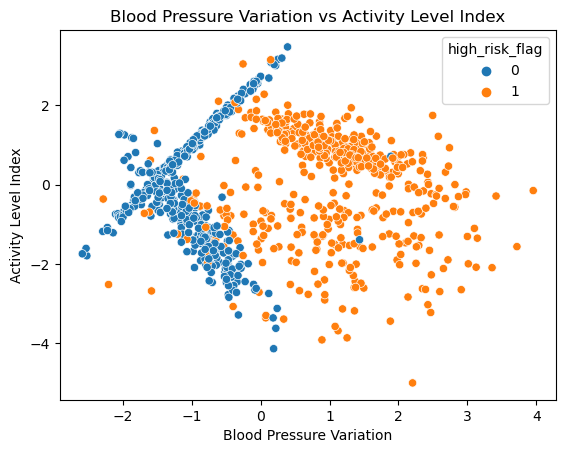

In [6]:
# Scatter plot, iki sayısal değişken arasındaki ilişkiyi görselleştirmek için kullanılan bir grafik türüdür. 
# Noktalar, her bir gözlemi temsil eder ve x ve y eksenlerinde ilgili değişkenlerin değerlerini gösterir. 
# Renkler veya şekiller, ek kategorik değişkenleri temsil etmek için kullanılabilir, bu da verilerdeki desenleri ve ilişkileri daha kolay tanımlamaya yardımcı olur.
# Bu görselleştirme, sağlık risklerini değerlendirmek için önemli olan kan basıncı dalgalanmaları ve aktivite seviyeleri arasındaki ilişkiyi anlamaya yardımcı olabilir. Yüksek riskli bireylerin genellikle daha yüksek kan basıncı dalgalanmalarına ve daha düşük aktivite seviyelerine sahip olduğu gözlemlenebilir, bu da sağlık risklerini artırabilir.

# 'blood_pressure_variation' ve 'activity_level_index' arasındaki ilişkiyi görselleştirmek için scatter plot kullanılmıştır. 
# Noktalar, 'high_risk_flag' değişkenine göre renklendirilmiştir, böylece yüksek riskli ve düşük riskli bireylerin bu iki değişken arasındaki dağılımı kolayca görülebilir.
# Bu görselleştirme, yüksek riskli bireylerin genellikle daha yüksek kan basıncı dalgalanmalarına ve daha düşük aktivite seviyelerine sahip olduğunu gösterebilir, bu da sağlık risklerini artırabilir.
sns.scatterplot(x=df['blood_pressure_variation'],y=df['activity_level_index'],hue=df['high_risk_flag'])
plt.title('Blood Pressure Variation vs Activity Level Index')
plt.xlabel('Blood Pressure Variation')
plt.ylabel('Activity Level Index')
plt.show()

In [7]:
# 'high_risk_flag' değişkeninin dağılımını görmek için value_counts() kullanılmıştır.
# Bu, yüksek riskli ve düşük riskli bireylerin sayısını gösterir, böylece veri setindeki sınıf dengesini değerlendirmeye yardımcı olur.
# Eğer yüksek riskli bireylerin sayısı düşük riskli bireylerin sayısına göre çok az ise, bu durum modelin performansını etkileyebilir ve sınıf dengesizliği sorunlarına yol açabilir.
# Bu bilgi, model eğitimi sırasında sınıf dengesizliği ile başa çıkmak için stratejiler geliştirmeye yardımcı olabilir.
df['high_risk_flag'].value_counts() # 'high_risk_flag' değişkeninin dağılımını göstermektedir.

0    502
1    498
Name: high_risk_flag, dtype: int64

In [8]:
X=df.drop('high_risk_flag',axis=1) # Bağımsız değişkenler (features) olarak 'high_risk_flag' dışındaki tüm sütunlar seçilmiştir.
y=df['high_risk_flag'] # Bağımlı değişken (target) olarak 'high_risk_flag' seçilmiştir.

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15) # Veriyi eğitim ve test setlerine ayırır. 
# Test seti, verinin %25'ini içerir ve random_state ile sonuçların tekrarlanabilirliği sağlanır.

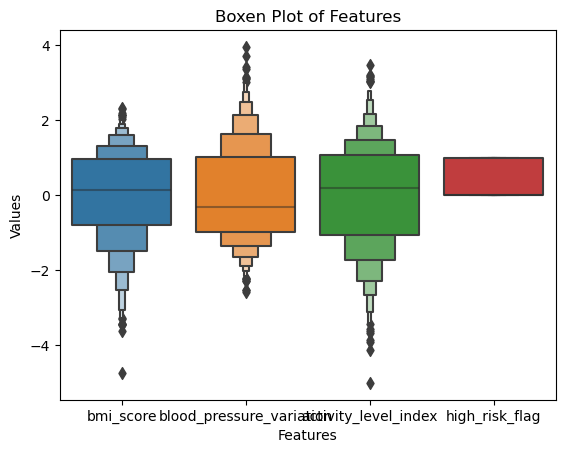

In [10]:
# Boxen plot, verilerin dağılımını ve merkezi eğilim ölçülerini görselleştirmek için kullanılan bir grafik türüdür.
# Bu görselleştirme, her bir özelliğin dağılımını ve olası aykırı değerleri tanımlamaya yardımcı olabilir, bu da model eğitimi sırasında önemli olabilir.
# Özellikle, yüksek riskli bireylerin belirli özelliklerde farklı dağılımlara sahip olup olmadığını görmek, modelin bu özellikleri nasıl kullanabileceği konusunda ipuçları verebilir.
sns.boxenplot(data=df) # Verilerin dağılımını görselleştirmek için boxen plot kullanılmıştır.
plt.title('Boxen Plot of Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

In [11]:
# #KNN algoritması, özellikle özellikler arasındaki mesafeye dayalı kararlar verdiği için, özelliklerin aynı ölçeklendirme ile işlenmesi önemlidir. 
# Bu nedenle, StandardScaler ile verilerin standartlaştırılması bu model için kritik bir adımdır. 

# Veriler oluşturulmuş ve ölçeklendirilmiş gibi görünse de, gerçek hayatta unutulmaması için scaler uygulanmalıdır.
# Bu adım, özellikle gerçek dünyadaki veriler genellikle farklı ölçeklerde olduğunda önemlidir.

In [12]:
# StandardScaler, verilerin ortalamasını 0 ve standart sapmasını 1 yaparak özellikleri standartlaştırır. 
# Bu, özellikle KNN gibi algoritmalar için önemlidir, çünkü bu algoritmalar özellikler arasındaki mesafeye dayalı kararlar verir.
# Ayrıca, test verisi eğitim verisine fit edilen scaler kullanılarak dönüştürülür, böylece veri sızıntısı önlenir ve modelin gerçek performansı daha doğru bir şekilde değerlendirilir.
scaler = StandardScaler() # StandardScaler, verilerin ortalamasını 0 ve standart sapmasını 1 yaparak özellikleri standartlaştırır.

X_train_scaled = scaler.fit_transform(X_train) # Eğitim verisine fit edilir ve aynı zamanda dönüştürülür. Bu, eğitim verisinin ortalamasını 0 ve standart sapmasını 1 yapar.
X_test_scaled = scaler.transform(X_test) # Test verisi, eğitim verisine fit edilen scaler kullanılarak dönüştürülür. Bu, test verisinin aynı ölçeklendirme ile işlenmesini sağlar, ancak test verisine fit edilmez, böylece veri sızıntısı önlenir.

In [ ]:
# KNeighborsClassifier, K-en yakın komşu algoritmasını kullanarak sınıflandırma yapan bir modeldir.

# n_neighbors parametresi, sınıflandırma kararını verirken kaç komşunun dikkate alınacağını belirler. 
# Bu değer, modelin esnekliğini ve genelleme yeteneğini etkiler. 
# Genellikle, daha düşük bir n_neighbors değeri modelin daha esnek olmasına ve eğitim verisine daha iyi uyum sağlamasına neden olabilir, ancak bu durum aşırı öğrenmeye (overfitting) yol açabilir.
# Daha yüksek bir n_neighbors değeri ise modelin daha genelleştirilebilir olmasına yardımcı olabilir, ancak bu durum modelin eğitim verisine yeterince uyum sağlamamasına (underfitting) neden olabilir. 
# Genellikle, n_neighbors değeri 3 ile 10 arasında seçilir (default değeri 5'tir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# weights parametresi, komşuların sınıflandırma kararına katkısını belirler.
# Genellikle, weights parametresi 'uniform' veya 'distance' olarak seçilir (default değeri 'uniform'dur), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.
# 'uniform' seçeneği, tüm komşuların eşit ağırlıkta olduğunu varsayar, yani her komşu sınıflandırma kararına aynı derecede katkıda bulunur. 
# 'distance' seçeneği ise, komşuların sınıflandırma kararına katkısının, komşuların hedef örneğe olan uzaklığına bağlı olduğunu varsayar. Bu durumda, daha yakın komşular daha yüksek ağırlık alır ve sınıflandırma kararına daha fazla katkıda bulunur. 
# 'distance' seçeneği, özellikle veri setinde gürültü (noise) varsa veya bazı komşuların hedef örneğe çok yakın olduğu durumlarda daha iyi performans gösterebilir, çünkü bu durumda daha yakın komşuların sınıflandırma kararına daha fazla katkıda bulunması mantıklı olabilir.

# leaf_size parametresi, yapının yaprak düğümlerinde kaç örneğin bulunacağını belirler. Bu değer, komşu arama algoritmasının performansını etkiler.
# Daha küçük bir leaf_size değeri, daha fazla yaprak düğümü oluşturur ve bu da komşu arama süresini azaltabilir, ancak daha fazla bellek kullanımına neden olabilir. 
# Daha büyük bir leaf_size değeri ise daha az yaprak düğümü oluşturur ve bu da bellek kullanımını azaltabilir, ancak komşu arama süresini artırabilir. 
# Genellikle, leaf_size değeri 20 ile 40 arasında seçilir (default değeri 30'dur), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# p parametresi, Minkowski mesafe metriği için kullanılan güç parametresini belirler.
# p=1, Manhattan mesafesini (L1 normu) kullanır, p=2 ise Öklid mesafesini (L2 normu) kullanır.
# p değeri, modelin komşular arasındaki mesafeyi nasıl hesaplayacağını belirler ve bu da modelin performansını etkileyebilir. 
# Örneğin, p=1, özellikle yüksek boyutlu verilerde daha iyi performans gösterebilir, çünkü Manhattan mesafesi, yüksek boyutlu verilerde daha az etkilenir. 
# p=2 ise, özellikle düşük boyutlu verilerde daha iyi performans gösterebilir, çünkü Öklid mesafesi, düşük boyutlu verilerde daha etkili olabilir. 
# Genellikle, p değeri 1 veya 2 olarak seçilir (default değeri 2'dir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.

# metric parametresi, komşular arasındaki mesafeyi hesaplamak için kullanılan metriği belirler.
# 'minkowski' seçeneği, Minkowski mesafe metriğini kullanır ve p parametresi ile birlikte çalışır. Minkowski mesafesi, p parametresine bağlı olarak farklı mesafe türlerini hesaplayabilir (örneğin, p=1 için Manhattan mesafesi, p=2 için Öklid mesafesi).
# 'euclidean' seçeneği, Öklid mesafesini kullanır ve p parametresine bağlı değildir. Bu seçenek, özellikle düşük boyutlu verilerde daha iyi performans gösterebilir, çünkü Öklid mesafesi, düşük boyutlu verilerde daha etkili olabilir.
# 'manhattan' seçeneği, Manhattan mesafesini kullanır ve p parametresine bağlı değildir. Bu seçenek, özellikle yüksek boyutlu verilerde daha iyi performans gösterebilir, çünkü Manhattan mesafesi, yüksek boyutlu verilerde daha az etkilenir. 
# Genellikle, metric parametresi 'minkowski', 'euclidean' veya 'manhattan' olarak seçilir (default değeri 'minkowski'dir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.   

# n_jobs parametresi, komşu arama işlemi için kullanılacak CPU çekirdeği sayısını belirler.
# -1 değeri, tüm çekirdeklerin kullanılmasını sağlar, bu da büyük veri setlerinde komşu arama süresini önemli ölçüde azaltabilir. 
# Ancak, bu durum, diğer işlemlerin performansını etkileyebilir, çünkü tüm çekirdekler komşu arama işlemi için kullanılır. 
# Genellikle, n_jobs değeri -1 olarak seçilir (default değeri -1'dir), ancak sistem kaynaklarına ve diğer işlemlerin performansına bağlı olarak optimize edilebilir.

# algorithm parametresi, komşuları bulmak için hangi algoritmanın kullanılacağını belirtir. 
# 'auto' seçeneği, uygun algoritmayı otomatik olarak seçer. Bu değer, veri setinin boyutuna ve özelliklerine bağlı olarak en iyi performansı sağlayacak algoritmayı seçer.
# ball_tree, kd_tree ve brute algoritmaları arasından seçim yapabilir. Ball_tree ve kd_tree, büyük veri setlerinde daha hızlı komşu arama sağlar, ancak küçük veri setlerinde brute algoritması daha iyi performans gösterebilir.
# ball_tree algoritması, yüksek boyutlu verilerde daha iyi performans gösterebilirken, kd_tree algoritması düşük boyutlu verilerde daha hızlı olabilir. Brute algoritması ise tüm veri setini tarayarak komşuları bulur ve küçük veri setlerinde etkili olabilir.

# Bu model, eğitim verisi üzerinde fit edilir, böylece model öğrenir ve daha sonra test verisi üzerinde tahminler yapabilir.

# Bu modelde n_neighbors değeri 5 olarak belirlenmiştir, bu da sınıflandırma kararını verirken en yakın 5 komşunun dikkate alınacağı anlamına gelir.
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [14]:
y_pred=classifier.predict(X_test_scaled) # Test verisi üzerinde tahminler yapar. Bu, modelin öğrenilen desenlere dayanarak test verisindeki örneklerin hangi sınıfa ait olduğunu tahmin etmesini sağlar.

In [15]:
# confusion_matrix, modelin tahminlerinin doğruluğunu değerlendirmek için kullanılan bir araçtır.
# Bu matris, gerçek sınıflar ile modelin tahmin ettiği sınıflar arasındaki ilişkiyi gösterir.
# Her bir hücre, belirli bir gerçek sınıf ile belirli bir tahmin edilen sınıfın kesişimini temsil eder.       
# Bu matris, modelin hangi sınıfları doğru tahmin ettiğini ve hangi sınıflarda hata yaptığını anlamaya yardımcı olur.
# Bu bilgi, modelin performansını değerlendirmek ve iyileştirmek için önemli bir adımdır.

# Degerler, modelin doğru tahmin ettiği örneklerin sayısını (true positives ve true negatives) ve yanlış tahmin ettiği örneklerin sayısını (false positives ve false negatives) gösterir.
# Degerler sırasıyla şu şekilde yorumlanır:
# - True Positives (TP): Modelin doğru bir şekilde yüksek riskli bireyleri tahmin ettiği durumlar.
# - True Negatives (TN): Modelin doğru bir şekilde düşük riskli bireyleri tahmin ettiği durumlar.
# - False Positives (FP): Modelin yanlış bir şekilde düşük riskli bireyleri yüksek riskli olarak tahmin ettiği durumlar.
# - False Negatives (FN): Modelin yanlış bir şekilde yüksek riskli bireyleri düşük riskli olarak tahmin ettiği durumlar.    
# Degerler ne kadar yüksekse, modelin o sınıfı o kadar iyi tahmin ettiği anlamına gelir. 
# Örneğin, yüksek bir TP değeri, modelin yüksek riskli bireyleri doğru bir şekilde tanımlama yeteneğinin iyi olduğunu gösterir.
# Benzer şekilde, yüksek bir TN değeri, modelin düşük riskli bireyleri doğru bir şekilde tanımlama yeteneğinin iyi olduğunu gösterir. 
# Ancak, yüksek FP veya FN değerleri, modelin belirli sınıfları yanlış tahmin etme eğiliminde olduğunu gösterebilir ve bu durum modelin performansını olumsuz etkileyebilir.

print("Confusion matrix: \n", confusion_matrix(y_pred,y_test)) # Confusion matrix değerleri gösterilir.

Confusion matrix: 
 [[124  10]
 [  2 114]]


In [16]:
# accuracy_score, modelin doğruluğunu ölçmek için kullanılan bir metriktir.
# Bu metrik, modelin doğru tahmin ettiği örneklerin toplam tahmin edilen örnekler içindeki oranını verir.
# Accuracy değeri ne kadar yüksekse, modelin genel olarak doğru tahminler yapma yeteneği o kadar iyi olur.
# # Bu bilgi, modelin performansını değerlendirmek ve iyileştirmek için önemli bir adımdır.

# Accuracy, modelin genel performansını değerlendirmek için yaygın olarak kullanılan bir metriktir, ancak sınıf dengesizliği durumlarında yanıltıcı olabilir.
# Örneğin, eğer veri setinde yüksek riskli bireylerin sayısı çok az ise, modelin çoğu tahmini düşük riskli bireyler için yapması durumunda yüksek bir accuracy değeri elde edilebilir, ancak bu durum modelin yüksek riskli bireyleri tanımlama yeteneğinin zayıf olduğunu gösterebilir.

print("Accuracy Score: ", accuracy_score(y_pred,y_test)) # accuracy score değeri gösterilir.

Accuracy Score:  0.952


In [17]:
# classification_report, modelin performansını değerlendirmek için kullanılan bir araçtır.
# Classification report, modelin her bir sınıf için precision, recall, f1-score ve support değerlerini gösterir.
# Bu rapor, modelin her bir sınıf için performansını detaylı bir şekilde değerlendirmeye yardımcı olur.

# Precision, modelin doğru pozitif tahminlerinin toplam pozitif tahminlere oranını gösterir.
# Yani, modelin pozitif olarak tahmin ettiği örneklerin ne kadarının gerçekten pozitif olduğunu gösterir.
# Daha yüksek bir precision değeri, modelin pozitif tahminlerinin daha doğru olduğunu gösterir, bu da özellikle yanlış pozitiflerin maliyetli olduğu durumlarda önemlidir.

# Recall, modelin doğru pozitif tahminlerinin toplam gerçek pozitiflere oranını gösterir.
# Yani, modelin gerçek pozitif örneklerin ne kadarını doğru bir şekilde tahmin ettiğini gösterir.
# Daha yüksek bir recall değeri, modelin gerçek pozitif örneklerin daha fazlasını tanımlama yeteneğinin daha iyi olduğunu gösterir, bu da özellikle yanlış negatiflerin maliyetli olduğu durumlarda önemlidir. 

# F1-score, precision ve recall'un harmonik ortalamasıdır ve modelin dengeli performansını değerlendirir.
# F1-score, özellikle sınıf dengesizliği durumlarında önemli bir metriktir, çünkü bu durumlarda accuracy yanıltıcı olabilir.
# Daha yüksek bir F1-score değeri, modelin hem precision hem de recall açısından daha iyi performans gösterdiğini gösterir. 

# Support, her sınıfın gerçek örnek sayısını gösterir.
# Support değeri, modelin her bir sınıf için ne kadar veri olduğunu gösterir ve bu bilgi, modelin performansını değerlendirmek için önemlidir.
# Özellikle, sınıf dengesizliği durumlarında, support değerleri modelin hangi sınıflar için daha fazla veri olduğunu ve bu durumun modelin performansını nasıl etkileyebileceğini anlamaya yardımcı olabilir. 
# Daha yüksek bir support değeri, modelin o sınıf için daha fazla veri olduğunu gösterir, bu da modelin o sınıf için daha iyi performans gösterebileceği anlamına gelebilir.

print("Classification Report: \n", classification_report(y_pred, y_test)) # classification report değerleri gösterilir.

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [18]:
# algorithm parametresi, komşuları bulmak için hangi algoritmanın kullanılacağını belirtir. 
# 'auto' seçeneği, uygun algoritmayı otomatik olarak seçer. Bu değer, veri setinin boyutuna ve özelliklerine bağlı olarak en iyi performansı sağlayacak algoritmayı seçer.
# ball_tree, kd_tree ve brute algoritmaları arasından seçim yapabilir. Ball_tree ve kd_tree, büyük veri setlerinde daha hızlı komşu arama sağlar, ancak küçük veri setlerinde brute algoritması daha iyi performans gösterebilir.
# ball_tree algoritması, yüksek boyutlu verilerde daha iyi performans gösterebilirken, kd_tree algoritması düşük boyutlu verilerde daha hızlı olabilir. Brute algoritması ise tüm veri setini tarayarak komşuları bulur ve küçük veri setlerinde etkili olabilir.
# Bu model, eğitim verisi üzerinde fit edilir, böylece model öğrenir ve daha sonra test verisi üzerinde tahminler yapabilir.

classifier=KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree') # this won't change the overall accuracy but maybe calculation time
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [19]:
y_pred=classifier.predict(X_test_scaled)

print("Confusion Matrix: \n", confusion_matrix(y_pred,y_test))
print("Accuracy Score: ", accuracy_score(y_pred,y_test))
print("Classification Report: \n", classification_report(y_pred,y_test))

Confusion Matrix: 
 [[124  10]
 [  2 114]]
Accuracy Score:  0.952
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [20]:
# what can change the overall accuracy is k number

In [21]:
# n_neighbors değeri, sınıflandırma kararını verirken kaç komşunun dikkate alınacağını belirler. 
# Bu değer, modelin esnekliğini ve genelleme yeteneğini etkiler. 
# Genellikle, daha düşük bir n_neighbors değeri modelin daha esnek olmasına ve eğitim verisine daha iyi uyum sağlamasına neden olabilir, ancak bu durum aşırı öğrenmeye (overfitting) yol açabilir.
# Daha yüksek bir n_neighbors değeri ise modelin daha genelleştirilebilir olmasına yardımcı olabilir, ancak bu durum modelin eğitim verisine yeterince uyum sağlamamasına (underfitting) neden olabilir. 
# Genellikle, n_neighbors değeri 3 ile 10 arasında seçilir (default değeri 5'tir), ancak en iyi performansı sağlamak için çapraz doğrulama (cross-validation) kullanılarak optimize edilebilir.
classifier=KNeighborsClassifier(n_neighbors=3,algorithm='auto') # n_neighbors değeri 3 olarak belirlenmiştir, bu da sınıflandırma kararını verirken en yakın 3 komşunun dikkate alınacağı anlamına gelir.
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [22]:
y_pred=classifier.predict(X_test_scaled)

print("Confusion Matrix: \n", confusion_matrix(y_pred,y_test))
print("Accuracy Score: ", accuracy_score(y_pred,y_test))
print("Classification Report: \n", classification_report(y_pred,y_test))

Confusion Matrix: 
 [[125   9]
 [  1 115]]
Accuracy Score:  0.96
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250

